# Análisis Exploratorio de Datos (EDA)
Este notebook realiza el análisis exploratorio, limpieza y preprocesamiento de características para la predicción de diabetes.

In [1]:
# 1. Carga de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import joblib
from sklearn.preprocessing import StandardScaler

# 2. Carga del dataset

In [2]:
# Definir rutas
DATA_PATH = Path('diabetes-dataset.csv')
PLOTS_DIR = Path('plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
SCALER_PATH = Path('../api/scaler.pkl')
SCALER_PATH.parent.mkdir(parents=True, exist_ok=True)
REPORT_PATH = Path('eda_report.md')

# Cargar dataset
df = pd.read_csv(DATA_PATH)
print(f"Dimensiones del dataset: {df.shape}")
display(df.head())
print("Nombres de columnas:", df.columns.tolist())

Dimensiones del dataset: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Nombres de columnas: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


# 3. Inspección inicial

In [3]:
df.info()
print("\nDescripción estadística:")
display(df.describe())
print("\nValores nulos por columna:")
print(df.isnull().sum())
print("\nCantidad de duplicados:", df.duplicated().sum())
print("\nTipos de datos:")
print(df.dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Descripción estadística:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



Valores nulos por columna:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Cantidad de duplicados: 0

Tipos de datos:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


# 4. Detección de ceros inválidos
Biológicamente, variables como `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` y `BMI` no pueden tener valor 0. Representan valores faltantes.

In [4]:
cols_invalid_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
total_records = len(df)

zero_stats = []
for col in cols_invalid_zeros:
    zero_count = (df[col] == 0).sum()
    zero_stats.append({
        'Variable': col,
        'Total Registros': total_records,
        'Cantidad Ceros': zero_count,
        'Porcentaje (%)': round((zero_count / total_records) * 100, 2)
    })

df_zeros = pd.DataFrame(zero_stats)
display(df_zeros)

,Variable,Total Registros,Cantidad Ceros,Porcentaje (%)
0,Glucose,768,5,0.65
1,BloodPressure,768,35,4.56
2,SkinThickness,768,227,29.56
3,Insulin,768,374,48.70
4,BMI,768,11,1.43


# Limpieza y Preprocesamiento
1. Reemplazar ceros por NaN
2. Imputar con la mediana
3. Separar X, y
4. Aplicar StandardScaler
5. Guardar scaler

In [5]:
# 1. Reemplazar ceros por NaN
df[cols_invalid_zeros] = df[cols_invalid_zeros].replace(0, np.nan)

# 2. NaN generados
print("NaN generados por columna:\n", df[cols_invalid_zeros].isnull().sum())

# 3. Imputar con mediana
for col in cols_invalid_zeros:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# 4. Validar sin NaN
assert df.isnull().sum().sum() == 0, "Aún hay NaN en el dataset!"
print("\nNo quedan NaN tras la imputación.")

# 5. Separar features
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# 6. Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# 7. Guardar scaler
joblib.dump(scaler, SCALER_PATH)
print(f"\nScaler guardado exitosamente en: {SCALER_PATH.resolve()}")

# 8. Verificación
assert SCALER_PATH.exists(), "No se pudo guardar el scaler" 

NaN generados por columna:
 Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

No quedan NaN tras la imputación.

Scaler guardado exitosamente en: /home/dragodeidad/Documents/screen-clinico/api/scaler.pkl


# Visualizaciones EDA

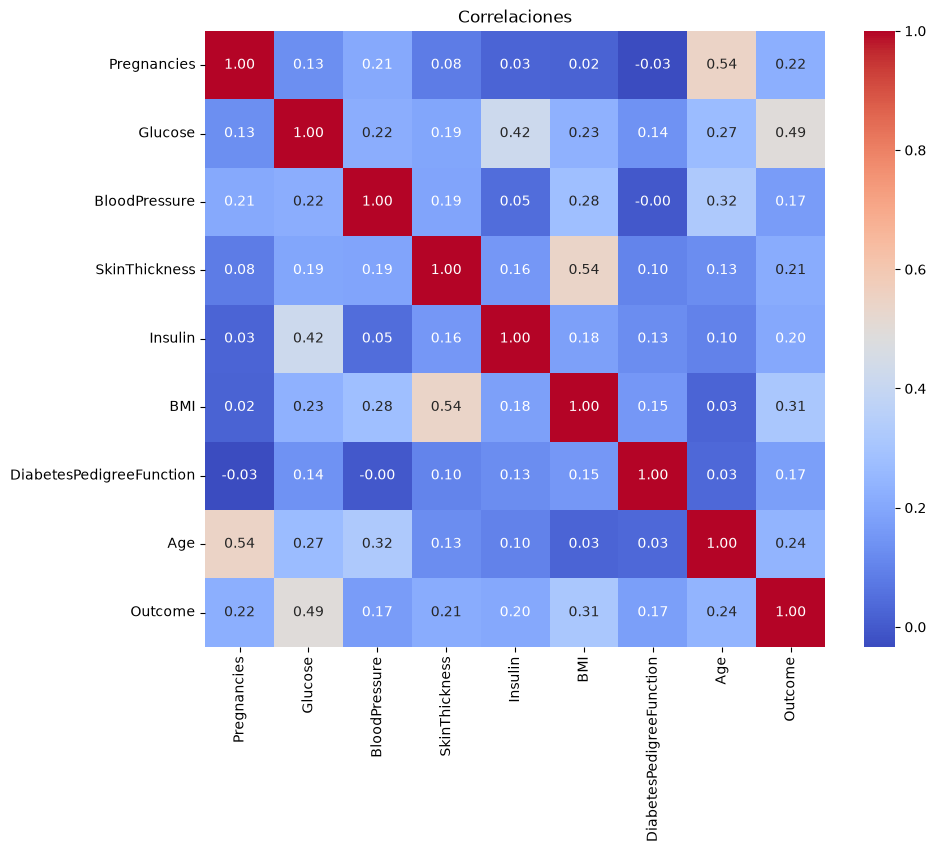

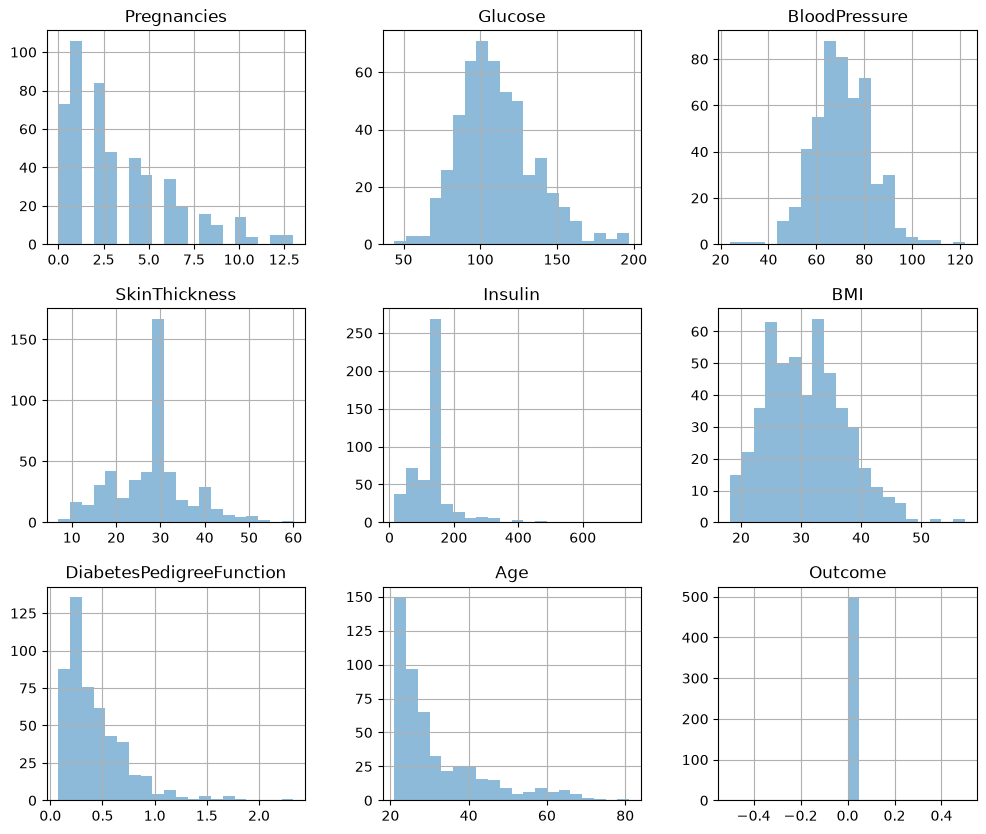

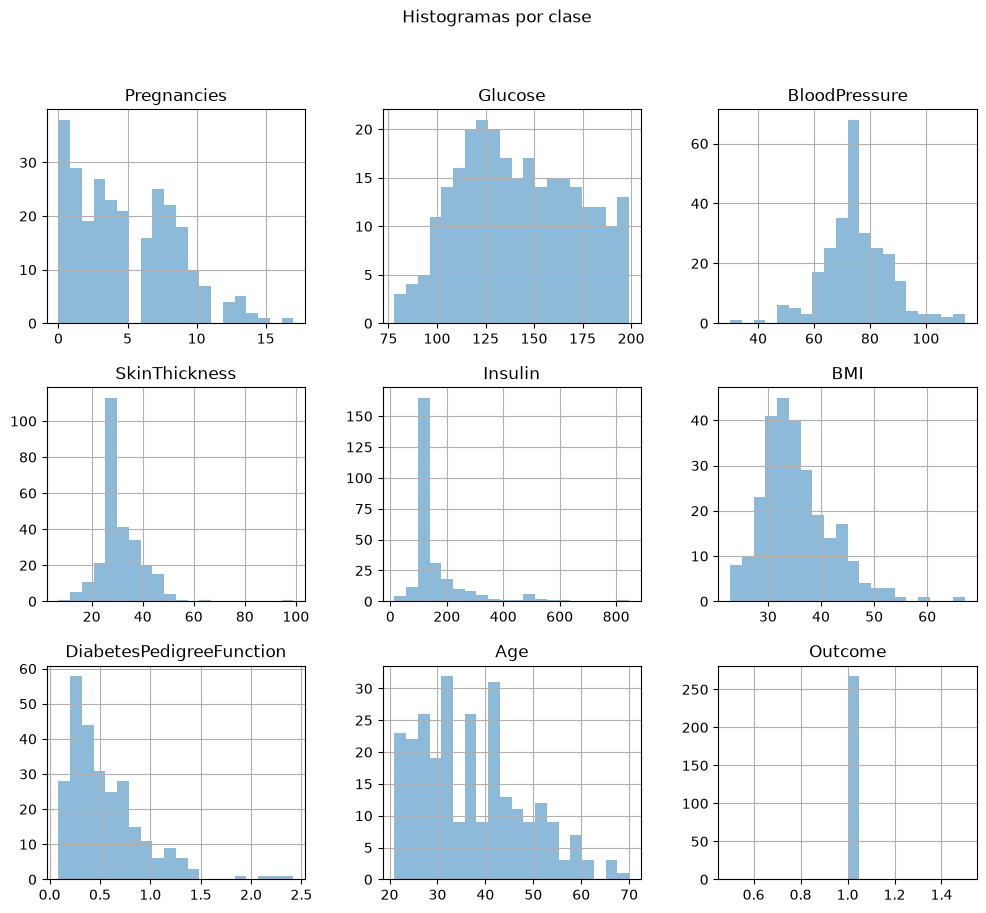

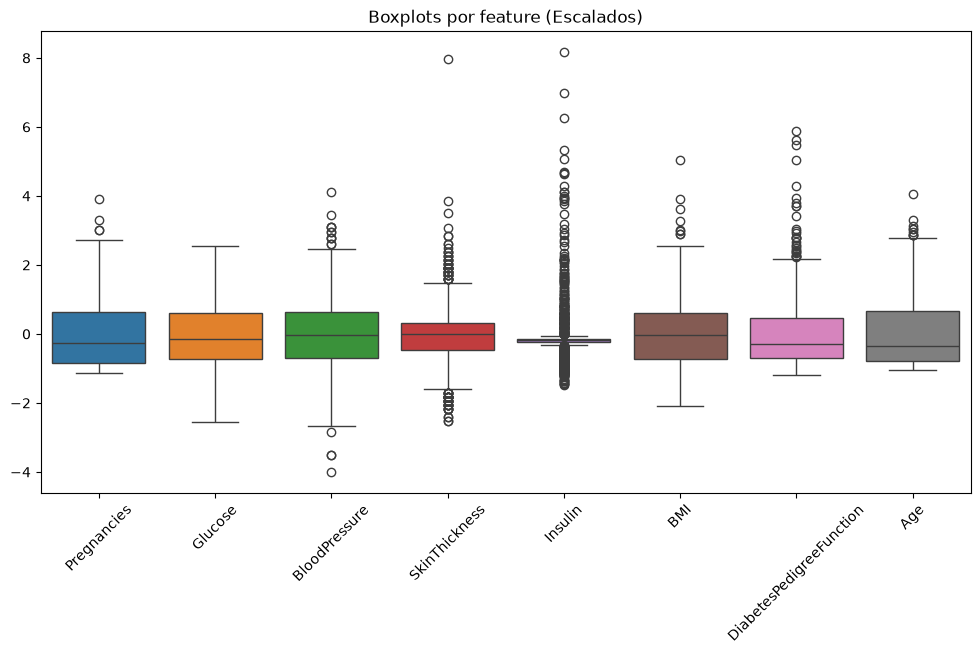

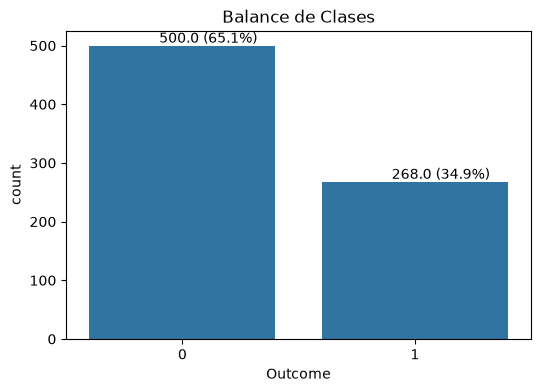

In [6]:
# 1. Heatmap de correlaciones
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlaciones')
plt.savefig(PLOTS_DIR / 'correlation_heatmap.png', bbox_inches='tight')
plt.show()

# 2. Histogramas por clase
df.groupby('Outcome').hist(figsize=(12, 10), alpha=0.5, bins=20)
plt.suptitle('Histogramas por clase')
plt.savefig(PLOTS_DIR / 'class_histograms.png', bbox_inches='tight')
plt.show()

# 3. Boxplots por feature
plt.figure(figsize=(12, 6))
sns.boxplot(data=X_scaled_df)
plt.xticks(rotation=45)
plt.title('Boxplots por feature (Escalados)')
plt.savefig(PLOTS_DIR / 'boxplots.png', bbox_inches='tight')
plt.show()

# 4. Distribución de clases
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x='Outcome')
plt.title('Balance de Clases')
for p in ax.patches:
    ax.annotate(f'{p.get_height()} ({(p.get_height()/len(df))*100:.1f}%)', (p.get_x() + 0.3, p.get_height() + 5))
plt.savefig(PLOTS_DIR / 'class_balance.png', bbox_inches='tight')
plt.show()

# Reporte Académico

In [7]:
md_content = f"""# Reporte Académico de EDA

## Introducción
El dataset contiene {total_records} registros clínicos para predecir la aparición de diabetes (Outcome). 

## Calidad de datos
Se identificaron ceros inválidos que representaban datos faltantes:
{df_zeros.to_markdown(index=False)}

## Limpieza realizada
- Reemplazo de ceros biológicamente imposibles por `NaN`.
- Imputación mediante la mediana de la columna correspondiente para evitar el impacto de outliers.
- Estandarización de todas las características predictivas usando `StandardScaler`. El scaler fue guardado para producción en `api/scaler.pkl`.

## Correlaciones
Las variables más positivamente correlacionadas con Outcome son:
- Glucose: {corr['Outcome']['Glucose']:.2f}
- BMI: {corr['Outcome']['BMI']:.2f}

## Balance de clases
- Cantidad de Outcome=0: {len(df[df['Outcome']==0])} ({(len(df[df['Outcome']==0])/total_records)*100:.1f}%)
- Cantidad de Outcome=1: {len(df[df['Outcome']==1])} ({(len(df[df['Outcome']==1])/total_records)*100:.1f}%)
Existe un moderado desbalance de clases (cerca de 2:1), lo cual es común en dominios médicos pero debe tenerse en cuenta para las métricas del modelo (ej. preferir F1-Score sobre Accuracy).

## Hallazgos principales
1. **Datos faltantes ocultos:** Una gran proporción de registros en variables como SkinThickness ({df_zeros.loc[df_zeros['Variable']=='SkinThickness', 'Porcentaje (%)'].values[0]}%) e Insulin ({df_zeros.loc[df_zeros['Variable']=='Insulin', 'Porcentaje (%)'].values[0]}%) estaban en cero.
2. **Alta correlación Glucose-Outcome:** La glucosa es la variable individual más discriminatoria.
3. **Distribución asimétrica:** Múltiples variables presentaban colas pesadas antes del preprocesamiento.
4. **Relación Edad y Glucosa:** Existen patrones visibles donde pacientes con altos valores de glucosa tienden a pertenecer a Outcome=1.
5. **Outliers persistentes:** Los boxplots evidencian la existencia de algunos valores atípicos que el StandardScaler no elimina.

## Conclusiones
La limpieza profunda ha resultado en un set de datos libre de valores fisiológicamente imposibles. Las variables están escaladas y listas para alimentar algoritmos como SVM, Regresión Logística o Redes Neuronales. El scaler está preservado para su consumo en la API."""

with open(REPORT_PATH, 'w', encoding='utf-8') as f:
    f.write(md_content)
    
print(f"Reporte generado en: {REPORT_PATH.resolve()}")

Reporte generado en: /home/dragodeidad/Documents/screen-clinico/data/eda_report.md
